# Dimensionality reduction and PCA

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if Path.cwd().name == "notebooks":
    os.chdir("..")

from minilearn.preprocessing.PCA import PCA
from minilearn.preprocessing.Scaler import StandardScalerMM
from minilearn.classifiers.logisiticRegressionFunc import LogisticRegressionMM
from minilearn.classifiers.SVM import SVMMM
from minilearn.classifiers.CART import CART
from minilearn.classifiers.NBG import GaussianNaiveBayesMM
from minilearn.classifiers.KNN import KNNClassifierMM
from minilearn.helper import ezcols

# Sklearn for comparison
from sklearn.decomposition import PCA as SkPCA
from sklearn.model_selection import train_test_split

# Adjust imports above to match your actual module paths

In [3]:
features = pd.read_csv("data/processed/features.csv")

print(features.shape)
features.head()

(2451, 496)


,filename,filepath,modality_number,modality,vocal_channel_number,vocal_channel,emotion_code,emotion,intensity_number,intensity,...,spec_centroid_min,spec_centroid_max,spec_bandwidth_mean,spec_bandwidth_std,spec_bandwidth_min,spec_bandwidth_max,spec_rolloff_mean,spec_rolloff_std,spec_rolloff_min,spec_rolloff_max
0,03-01-01-01-01-01-01.wav,data\Actor_01\03-01-01-01-01-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,14584.465982,5551.291828,1966.670942,0.000000,7941.362325,13285.735887,7873.634242,0.0000,20929.6875
1,03-01-01-01-01-02-01.wav,data\Actor_01\03-01-01-01-01-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,850.770544,12081.525541,5653.771579,1897.506371,2300.580933,8065.492390,13191.643371,7634.107567,960.9375,21140.6250
2,03-01-01-01-02-01-01.wav,data\Actor_01\03-01-01-01-02-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,12170.914340,5641.048020,2054.943735,0.000000,7938.570208,13279.137826,7981.393363,0.0000,21140.6250
3,03-01-01-01-02-02-01.wav,data\Actor_01\03-01-01-01-02-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,1001.254209,12108.222580,5802.315322,1915.796134,2313.602810,7918.679500,13272.074245,7570.671093,937.5000,21187.5000
4,03-01-02-01-01-01-01.wav,data\Actor_01\03-01-02-01-01-01-01.wav,3,audio-only,1,speech,2,calm,1,normal,...,0.000000,13533.883723,5518.637359,1916.039762,0.000000,8027.820710,12649.543486,7902.073642,0.0000,21585.9375


In [4]:
feature_cols = ezcols()

X = features[feature_cols]
y = features["emotion"]

print(X.shape)
print(y.value_counts())

(2451, 480)
emotion
calm         376
happy        376
sad          376
angry        376
fearful      376
surprised    192
disgust      191
neutral      188
Name: count, dtype: int64


Wanted to check how many features are needed I know that apaprently the standard is to take the top 2, but I think I should go and try 50 vs 100 and then see which one is better. I feel like a 360 feature reduction down to 100 for 91% of variance is extremely good and probably what I will be going with. The sklearn model and the minilearn model both seem to be showing around the same amount of information. With SKlearns accuracy being a little bit lower at 100 components in.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20, shuffle=True
)

scaler = StandardScalerMM()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

n_features = X_train_scaled.shape[1]

sk_pca = SkPCA(n_components=n_features)
pca_full = PCA(n_components=n_features)
sk_pca.fit(X_train_scaled)
pca_full.fit(X_train_scaled)

mm_var   = pca_full.explained_variance_ratio
sk_var   = sk_pca.explained_variance_ratio_
mm_cum   = np.cumsum(mm_var)
sk_cum   = np.cumsum(sk_var)

explained_var = pca_full.explained_variance_ratio
cumulative_var = np.cumsum(explained_var)
print("=" * 50)
print("Minilearn PCA")
print(f"Total components: {n_features}")
print(f"Top 5 variance ratios: {explained_var[:5]}")
print(f"First component captures: {explained_var[0]*100:.2f}%")
print(f"First 10 components capture: {cumulative_var[9]*100:.2f}%")
print(f"First 50 components capture: {cumulative_var[49]*100:.2f}%")
print(f"First 100 components capture: {cumulative_var[99]*100:.2f}%")

explained_var1 = sk_pca.explained_variance_ratio_
cumulative_var1 = np.cumsum(explained_var1)
print("=" * 50)
print("SKLEARN PCA")
print(f"Total components: {n_features}")
print(f"Top 5 variance ratios: {explained_var1[:5]}")
print(f"First component captures: {explained_var1[0]*100:.2f}%")
print(f"First 10 components capture: {cumulative_var1[9]*100:.2f}%")
print(f"First 50 components capture: {cumulative_var1[49]*100:.2f}%")
print(f"First 100 components capture: {cumulative_var1[99]*100:.2f}%")


(1960, 480)
(491, 480)
Minilearn PCA
Total components: 480
Top 5 variance ratios: [0.11880997 0.10543511 0.08379682 0.06559495 0.04108839]
First component captures: 11.88%
First 10 components capture: 53.37%
First 50 components capture: 81.34%
First 100 components capture: 90.66%
SKLEARN PCA
Total components: 480
Top 5 variance ratios: [0.11880997 0.10543511 0.08379682 0.06559495 0.04108839]
First component captures: 11.88%
First 10 components capture: 53.37%
First 50 components capture: 81.34%
First 100 components capture: 90.66%


this gets us the exact number while up top onyl got us numbers by the amount of components

In [13]:
for thresh in [0.80, 0.90, 0.95, 0.99]:
    n_needed = np.searchsorted(mm_cum, thresh) + 1
    print(f"Need {n_needed:3d} components to explain {thresh*100:.0f}% of variance")

Need  46 components to explain 80% of variance
Need  95 components to explain 90% of variance
Need 147 components to explain 95% of variance
Need 251 components to explain 99% of variance


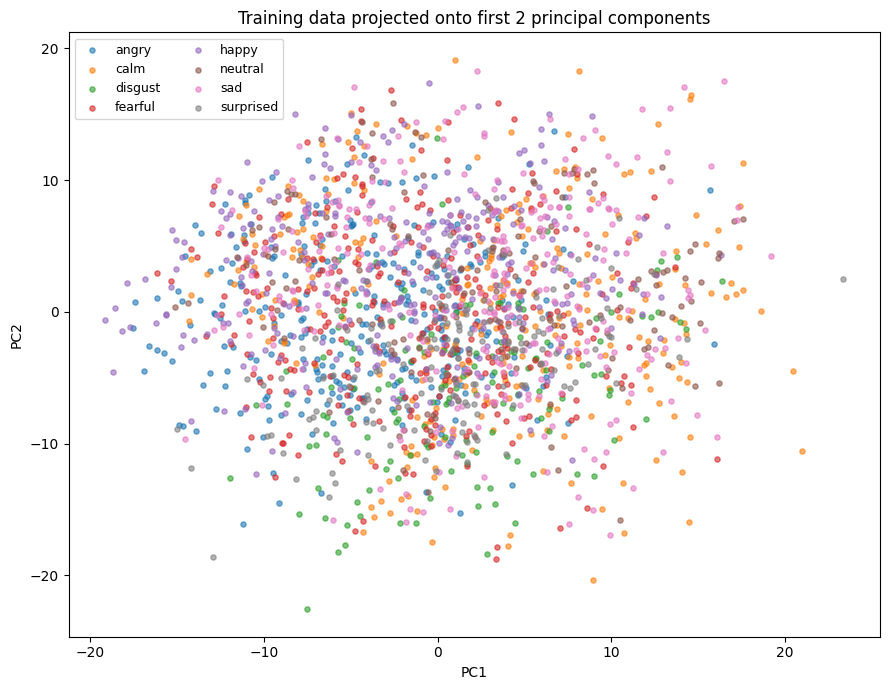

In [14]:
pca2 = PCA(n_components=2)
X_train_2d = pca2.fit_transform(X_train_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for e in np.unique(y_train):
    mask = y_train == e
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], s=14, alpha=0.6, label=e)
ax.set_title("Training data projected onto first 2 principal components")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

In [19]:
from minilearn.metrics.metricss import accuracy, f1_score


def eval_on_components(n_components, model_factory, X_tr, y_tr, X_te, y_te, labels):
    pca = PCA(n_components=n_components)
    pca.fit(X_tr)
    X_tr_red = pca.transform(X_tr)
    X_te_red = pca.transform(X_te)
    
    model = model_factory()
    model.fit(X_tr_red, y_tr)
    
    y_pred = model.predict(X_te_red)
    return {
        'n_components': n_components,
        'accuracy': accuracy(y_te, y_pred),
        'f1_macro': f1_score(y_te, y_pred, labels, average='macro'),
    }

labels = list(np.unique(y))
component_counts = [2, 10, 25, 50, 100, 150, 200]

# Pick classifiers to sweep -- LR and KNN are fast, SVM is fine, CART is OK
model_factories = {
    'LogReg': lambda: LogisticRegressionMM(lr=0.1, n_iters=1000),
    'KNN':    lambda: KNNClassifierMM(k=5),
    'NB':     lambda: GaussianNaiveBayesMM(),
    'CART':   lambda: CART(max_depth=5, minsplit=2),
    'SVM':    lambda: SVMMM(C=1, learning=0.001,max_iters=1000)
}

sweep_rows = []
for n in component_counts:
    print(f"-- n_components = {n}")
    for name, factory in model_factories.items():
        res = eval_on_components(n, factory, X_train_scaled, y_train, X_test_scaled, y_test, labels)
        sweep_rows.append({'Model': name, **res})
        print(f"   {name:7s} acc={res['accuracy']:.4f}  f1={res['f1_macro']:.4f}s")

sweep_df = pd.DataFrame(sweep_rows)
sweep_df

-- n_components = 2
   LogReg  acc=0.2525  f1=0.1964s
   KNN     acc=0.1914  f1=0.1866s
   NB      acc=0.2688  f1=0.2222s
   CART    acc=0.2464  f1=0.1626s
   SVM     acc=0.1670  f1=0.0358s
-- n_components = 10
   LogReg  acc=0.3870  f1=0.3674s
   KNN     acc=0.4236  f1=0.4089s
   NB      acc=0.3177  f1=0.2868s
   CART    acc=0.3299  f1=0.2909s
   SVM     acc=0.2138  f1=0.0974s
-- n_components = 25
   LogReg  acc=0.4114  f1=0.3992s
   KNN     acc=0.4807  f1=0.4405s
   NB      acc=0.3360  f1=0.3042s
   CART    acc=0.3238  f1=0.2733s
   SVM     acc=0.2444  f1=0.1184s
-- n_components = 50
   LogReg  acc=0.5784  f1=0.5676s
   KNN     acc=0.5397  f1=0.5127s
   NB      acc=0.4155  f1=0.3982s
   CART    acc=0.3299  f1=0.2968s
   SVM     acc=0.2444  f1=0.1235s
-- n_components = 100
   LogReg  acc=0.6558  f1=0.6493s
   KNN     acc=0.5499  f1=0.5214s
   NB      acc=0.4338  f1=0.4135s
   CART    acc=0.3381  f1=0.3204s
   SVM     acc=0.2444  f1=0.1239s
-- n_components = 150
   LogReg  acc=0.7088  

,Model,n_components,accuracy,f1_macro
0,LogReg,2,0.252546,0.196391
1,KNN,2,0.191446,0.186585
2,NB,2,0.268839,0.222201
3,CART,2,0.246436,0.162641
4,SVM,2,0.167006,0.035777
5,LogReg,10,0.386965,0.367361
6,KNN,10,0.423625,0.408899
7,NB,10,0.317719,0.286774
8,CART,10,0.329939,0.290944
9,SVM,10,0.213849,0.097442


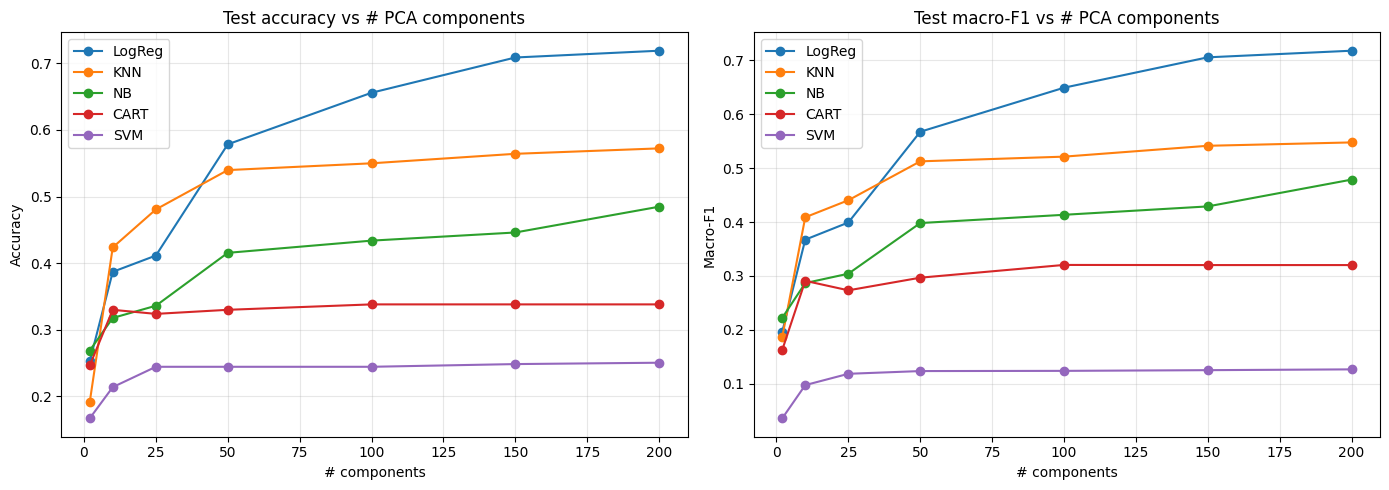

In [20]:
# Plot accuracy and f1 vs # components for each model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in model_factories.keys():
    sub = sweep_df[sweep_df['Model'] == name]
    axes[0].plot(sub['n_components'], sub['accuracy'], marker='o', label=name)
    axes[1].plot(sub['n_components'], sub['f1_macro'], marker='o', label=name)

axes[0].set_title("Test accuracy vs # PCA components")
axes[0].set_xlabel("# components"); axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title("Test macro-F1 vs # PCA components")
axes[1].set_xlabel("# components"); axes[1].set_ylabel("Macro-F1"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Baseline (no PCA) for each classifier on the same train/test split
baseline_rows = []

# Stratified 20% subset just for CART (CART is way too slow on full data)
rng = np.random.default_rng(20)
sub_idx = rng.choice(len(X_train_scaled), size=int(0.2 * len(X_train_scaled)), replace=False)
X_train_sub = X_train_scaled[sub_idx]
y_train_sub = np.asarray(y_train)[sub_idx]

for name, factory in model_factories.items():
    model = factory()
    if name == 'CART':
        model.fit(X_train_sub, y_train_sub)
        n_label = f'all ({n_features}, 20% subset)'
    else:
        model.fit(X_train_scaled, y_train)
        n_label = f'all ({n_features})'
    y_pred = model.predict(X_test_scaled)
    baseline_rows.append({
        'Model': name,
        'n_components': n_label,
        'accuracy': accuracy(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, labels, average='macro'),
    })

# Pick a reasonable PCA size (components needed for 90% variance)
n_90 = np.searchsorted(mm_cum, 0.90) + 1

pca_rows = []
for name, factory in model_factories.items():
    if name == 'CART':
        res = eval_on_components(n_90, factory, X_train_sub, y_train_sub, X_test_scaled, y_test, labels)
        pca_rows.append({
            'Model': name,
            'n_components': f'PCA-{n_90} (90% var, 20% subset)',
            **{k:v for k,v in res.items() if k != 'n_components'}
        })
    else:
        res = eval_on_components(n_90, factory, X_train_scaled, y_train, X_test_scaled, y_test, labels)
        pca_rows.append({
            'Model': name,
            'n_components': f'PCA-{n_90} (90% var)',
            **{k:v for k,v in res.items() if k != 'n_components'}
        })

compare_df = pd.DataFrame(baseline_rows + pca_rows).sort_values(['Model', 'n_components']).reset_index(drop=True)
compare_df

,Model,n_components,accuracy,f1_macro
0,CART,"PCA-95 (90% var, 20% subset)",0.258656,0.214572
1,CART,"all (480, 20% subset)",0.311609,0.284206
2,KNN,PCA-95 (90% var),0.547862,0.518401
3,KNN,all (480),0.580448,0.556076
4,LogReg,PCA-95 (90% var),0.663951,0.657339
5,LogReg,all (480),0.739308,0.740661
6,NB,PCA-95 (90% var),0.417515,0.393639
7,NB,all (480),0.274949,0.206617
8,SVM,PCA-95 (90% var),0.244399,0.122550
9,SVM,all (480),0.246436,0.124352
